In [ ]:
#Write a program on linear regression (using diamonds dataset)
#Step 1 : Import all the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [ ]:
#Step 2 : Load the diamonds dataset
diamonds = sns.load_dataset('diamonds')

In [ ]:
#Step 3 : Display the first few rows of dataset
print(diamonds.head(50))
#print(diamonds.shape())
#print(diamonds.describe())
#print(diamonds.info())

    carat        cut color clarity  depth  table  price     x     y     z
0    0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1    0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2    0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3    0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4    0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
5    0.24  Very Good     J    VVS2   62.8   57.0    336  3.94  3.96  2.48
6    0.24  Very Good     I    VVS1   62.3   57.0    336  3.95  3.98  2.47
7    0.26  Very Good     H     SI1   61.9   55.0    337  4.07  4.11  2.53
8    0.22       Fair     E     VS2   65.1   61.0    337  3.87  3.78  2.49
9    0.23  Very Good     H     VS1   59.4   61.0    338  4.00  4.05  2.39
10   0.30       Good     J     SI1   64.0   55.0    339  4.25  4.28  2.73
11   0.23      Ideal     J     VS1   62.8   56.0    340  3.93  3.90  2.46
12   0.22    Premium     F     SI1   6

In [ ]:
#Step 4 : Select features and target variable
features = ['carat', 'depth', 'table', 'x', 'y', 'z']
X = diamonds[features]
y = diamonds['price']

In [ ]:
#Step 5 : Convert categorical
clarity_dummies = pd.get_dummies(diamonds['clarity'], prefix='clarity')
print(clarity_dummies.head(50))
X = pd.concat([X, clarity_dummies], axis=1)

    clarity_IF  clarity_VVS1  clarity_VVS2  clarity_VS1  clarity_VS2  \
0        False         False         False        False        False   
1        False         False         False        False        False   
2        False         False         False         True        False   
3        False         False         False        False         True   
4        False         False         False        False        False   
5        False         False          True        False        False   
6        False          True         False        False        False   
7        False         False         False        False        False   
8        False         False         False        False         True   
9        False         False         False         True        False   
10       False         False         False        False        False   
11       False         False         False         True        False   
12       False         False         False        False        F

In [ ]:
#Step 6 : Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [ ]:
#Step 7 : Initialize the Linear regression model
model = LinearRegression()
#Train the model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Step 8 : Make prediction of the prices based on the features test set
y_pred = model.predict(X_test)

#Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error : {mse}")
print(f"R-Squared : {r2}")

Mean Squared Error : 1613865.155537295
R-Squared : 0.8984787518381911


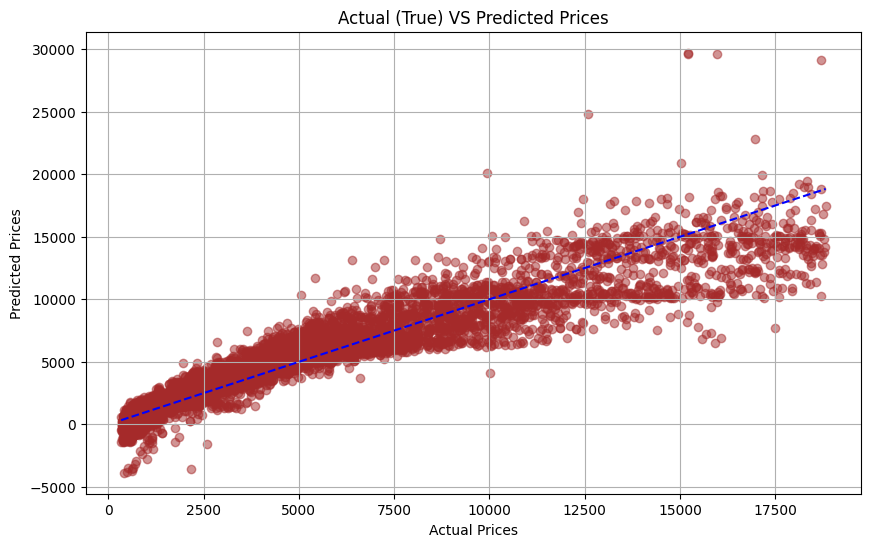

In [ ]:
#Step 9 : Plot the true VS predicted values
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color = '#A52A2A', alpha = 0.5)

#Plot the line of equality
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--b')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual (True) VS Predicted Prices')
plt.grid(True)
#plt.show()